In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the feature-engineered dataset

input_file = "../data/tourism_experience_features.csv"

df = pd.read_csv(input_file)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (52930, 32)


In [3]:
# Display the first few records

display(df.head(10))

,TransactionId,UserId,VisitYear,VisitMonth,AttractionId,Rating,ContinentId,RegionId,CountryId,CityId,...,RatingCategory,VisitYearMonth,UserVisitCount,AttractionVisitCount,AttractionAverageRating,AttractionPopularity,RatingScore,VisitYearGroup,UserAverageRating,CityVisitCount
0,3,70456,2022,10,640,5,5,21,163,4341.0,...,High,2022-10,1,13198,4.267086,Highly Popular,1.0,After 2020,5.000000,40.0
1,8,7567,2022,10,640,5,2,8,48,464.0,...,High,2022-10,1,13198,4.267086,Highly Popular,1.0,After 2020,5.000000,11.0
2,9,79069,2022,10,640,5,2,9,54,774.0,...,High,2022-10,1,13198,4.267086,Highly Popular,1.0,After 2020,5.000000,3.0
3,10,31019,2022,10,640,3,5,17,135,583.0,...,Average,2022-10,2,13198,4.267086,Highly Popular,0.6,After 2020,3.000000,80.0
4,15,43611,2022,10,640,3,5,21,163,1396.0,...,Average,2022-10,3,13198,4.267086,Highly Popular,0.6,After 2020,3.000000,204.0
5,18,43471,2022,10,640,5,2,8,51,1806.0,...,High,2022-10,2,13198,4.267086,Highly Popular,1.0,After 2020,5.000000,205.0
6,22,76492,2022,9,640,4,1,2,9,31.0,...,High,2022-09,2,13198,4.267086,Highly Popular,0.8,After 2020,4.000000,4.0
7,23,20977,2022,10,640,5,5,21,163,8258.0,...,High,2022-10,1,13198,4.267086,Highly Popular,1.0,After 2020,5.000000,79.0
8,28,18655,2022,9,640,3,1,4,22,114.0,...,Average,2022-09,1,13198,4.267086,Highly Popular,0.6,After 2020,3.000000,39.0
9,29,62907,2022,9,640,5,2,8,51,50.0,...,High,2022-09,14,13198,4.267086,Highly Popular,1.0,After 2020,3.928571,48.0


# Rating Analysis

Rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64

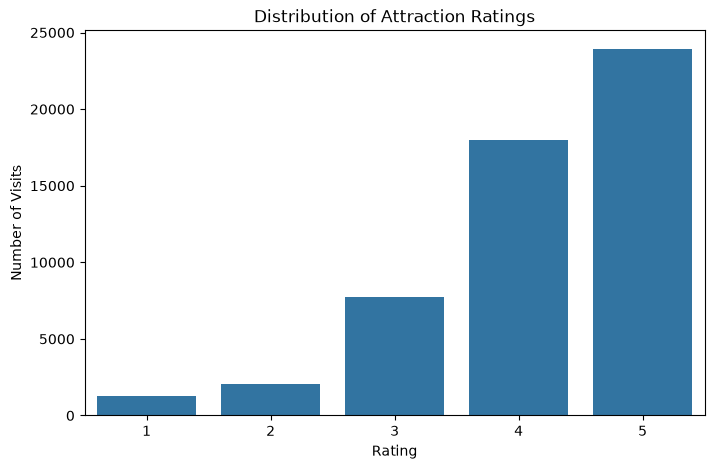

In [4]:
# Analyze the distribution of attraction ratings

rating_counts = df["Rating"].value_counts().sort_index()

display(rating_counts)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Rating",
    order=sorted(df["Rating"].dropna().unique())
)

plt.title("Distribution of Attraction Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Visits")

plt.show()

# Top 10 Most Visited Attractions

Attraction
Sacred Monkey Forest Sanctuary    13198
Waterbom Bali                      6429
Tegalalang Rice Terrace            5815
Uluwatu Temple                     3359
Tanah Lot Temple                   3352
Sanur Beach                        3044
Seminyak Beach                     2914
Kuta Beach - Bali                  2765
Merapi Volcano                     2235
Tegenungan Waterfall               2190
Name: TransactionId, dtype: int64

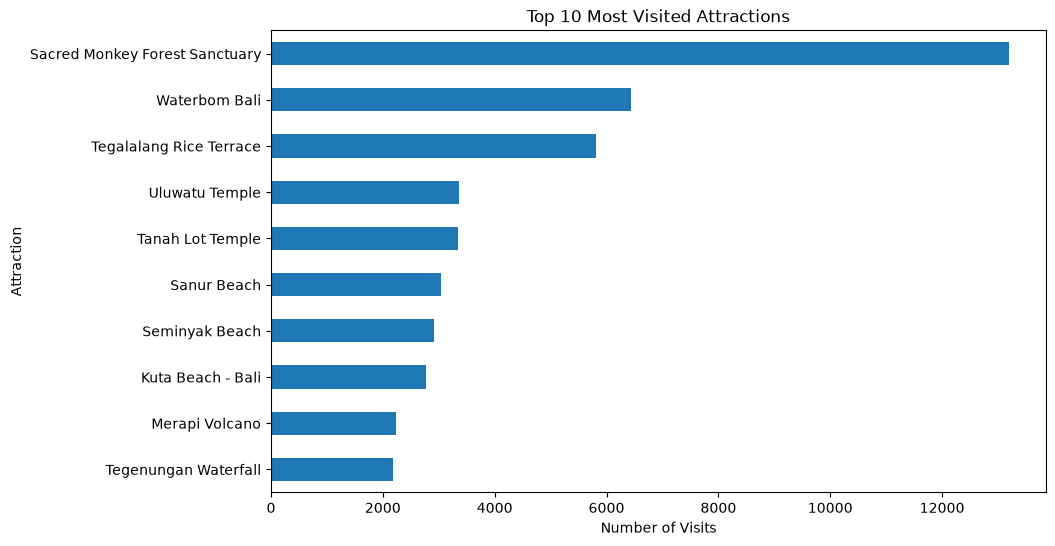

In [ ]:
# Find the 10 most visited attractions

top_attractions = (
    df.groupby("Attraction")["TransactionId"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

display(top_attractions)

plt.figure(figsize=(10, 6))

top_attractions.sort_values().plot(kind="barh")

plt.title("Top 10 Most Visited Attractions")
plt.xlabel("Number of Visits")
plt.ylabel("Attraction")

plt.show()

# Top 10 Cities by Visits

CityName
Douala          45170
N'Djamena        6931
South Region      829
Name: TransactionId, dtype: int64

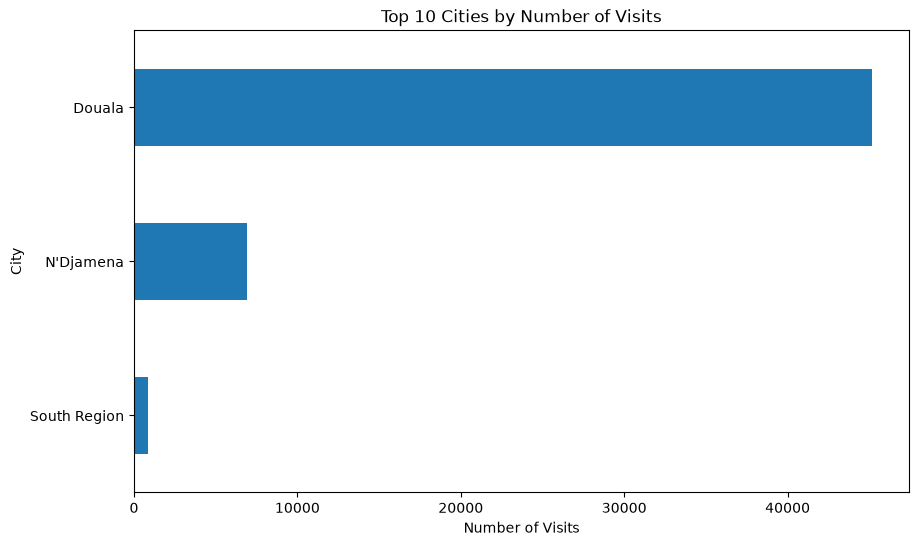

In [6]:
# Find the 10 cities with the highest number of tourism visits

city_visits = (
    df.groupby("CityName")["TransactionId"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

display(city_visits)

plt.figure(figsize=(10, 6))

city_visits.sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Number of Visits")
plt.xlabel("Number of Visits")
plt.ylabel("City")

plt.show()

# Top 10 Countries

Country
Australia         13322
United Kingdom     6722
United States      6261
Indonesia          4842
Singapore          2807
India              2543
Malaysia           1581
Canada             1486
New Zealand        1479
Netherlands         859
Name: count, dtype: int64

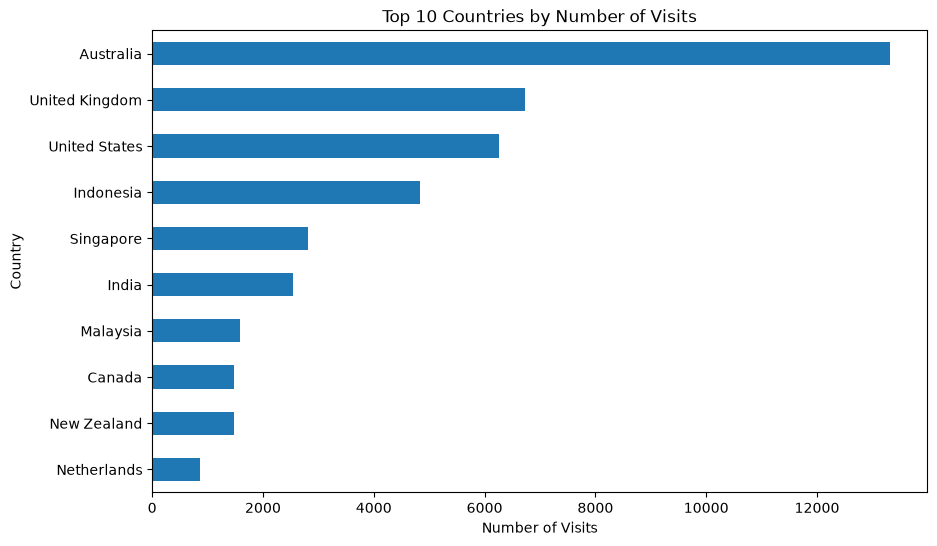

In [7]:
# Find the 10 countries with the highest number of visits

country_visits = df["Country"].value_counts().head(10)

display(country_visits)

plt.figure(figsize=(10, 6))

country_visits.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Number of Visits")
plt.xlabel("Number of Visits")
plt.ylabel("Country")

plt.show()

# Visit Mode Distribution

VisitMode
Couples     21620
Family      15217
Friends     10945
Solo         4525
Business      623
Name: count, dtype: int64

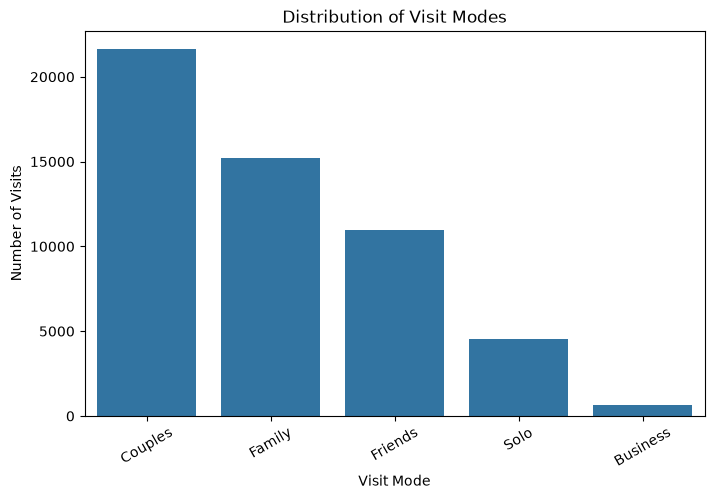

In [8]:
# Analyze how tourists visit attractions

visit_mode_counts = df["VisitMode"].value_counts()

display(visit_mode_counts)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=visit_mode_counts.index,
    y=visit_mode_counts.values
)

plt.title("Distribution of Visit Modes")
plt.xlabel("Visit Mode")
plt.ylabel("Number of Visits")

plt.xticks(rotation=30)

plt.show()

# Visit Over Time 

VisitYear
2013     2983
2014     4808
2015     8687
2016    12823
2017     9444
2018     7461
2019     5913
2020      529
2021       35
2022      247
Name: TransactionId, dtype: int64

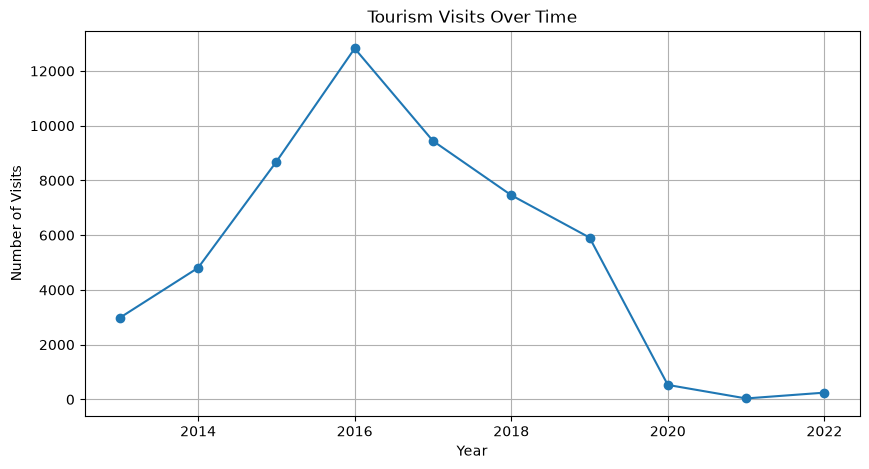

In [9]:
# Analyze the number of visits for each year

yearly_visits = (
    df.groupby("VisitYear")["TransactionId"]
    .count()
    .sort_index()
)

display(yearly_visits)

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_visits.index,
    yearly_visits.values,
    marker="o"
)

plt.title("Tourism Visits Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Visits")

plt.grid(True)

plt.show()

# Attraction Popularity vs Rating

,VisitCount,AverageRating
Attraction,,
Sacred Monkey Forest Sanctuary,13198,4.267086
Waterbom Bali,6429,4.646601
Tegalalang Rice Terrace,5815,4.157524
Uluwatu Temple,3359,4.219411
Tanah Lot Temple,3352,4.194809
Sanur Beach,3044,3.976347
Seminyak Beach,2914,3.800618
Kuta Beach - Bali,2765,3.415190
Merapi Volcano,2235,4.079195


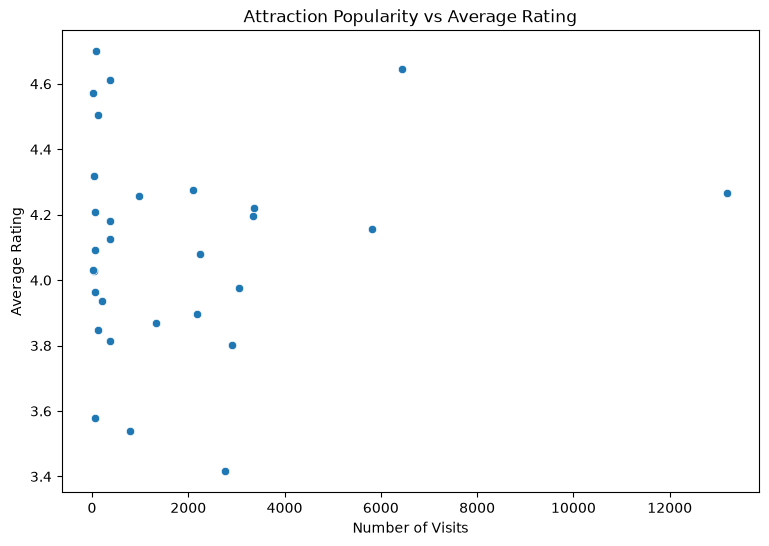


Analysis and Visualization completed successfully!


In [10]:
# Compare attraction popularity with average rating

attraction_analysis = (
    df.groupby("Attraction")
    .agg(
        VisitCount=("TransactionId", "count"),
        AverageRating=("Rating", "mean")
    )
)

display(
    attraction_analysis
    .sort_values("VisitCount", ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=attraction_analysis,
    x="VisitCount",
    y="AverageRating"
)

plt.title("Attraction Popularity vs Average Rating")
plt.xlabel("Number of Visits")
plt.ylabel("Average Rating")

plt.show()

print("\nAnalysis and Visualization completed successfully!")